# Tutorial 10 — π-Junction Phase Diagram

**Goal:** Map the 0–π phase boundary of an S/F bilayer in
$(d_F, \text{material})$ space and identify the **sweet-spot thickness**
for a robust π-junction.

A π-junction forms when the F-layer is thick enough that the
superconducting order parameter oscillates and reverses sign.
The 0–π boundary occurs where $T_c(\text{phase=zero})$ crosses
$T_c(\text{phase=pi})$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

supermag.apply_theme("publication")

## 1. Zero vs. π critical-temperature curves

Compute $T_c(d_F)$ for both the 0-state and the π-state.
The physical $T_c$ is whichever is higher.

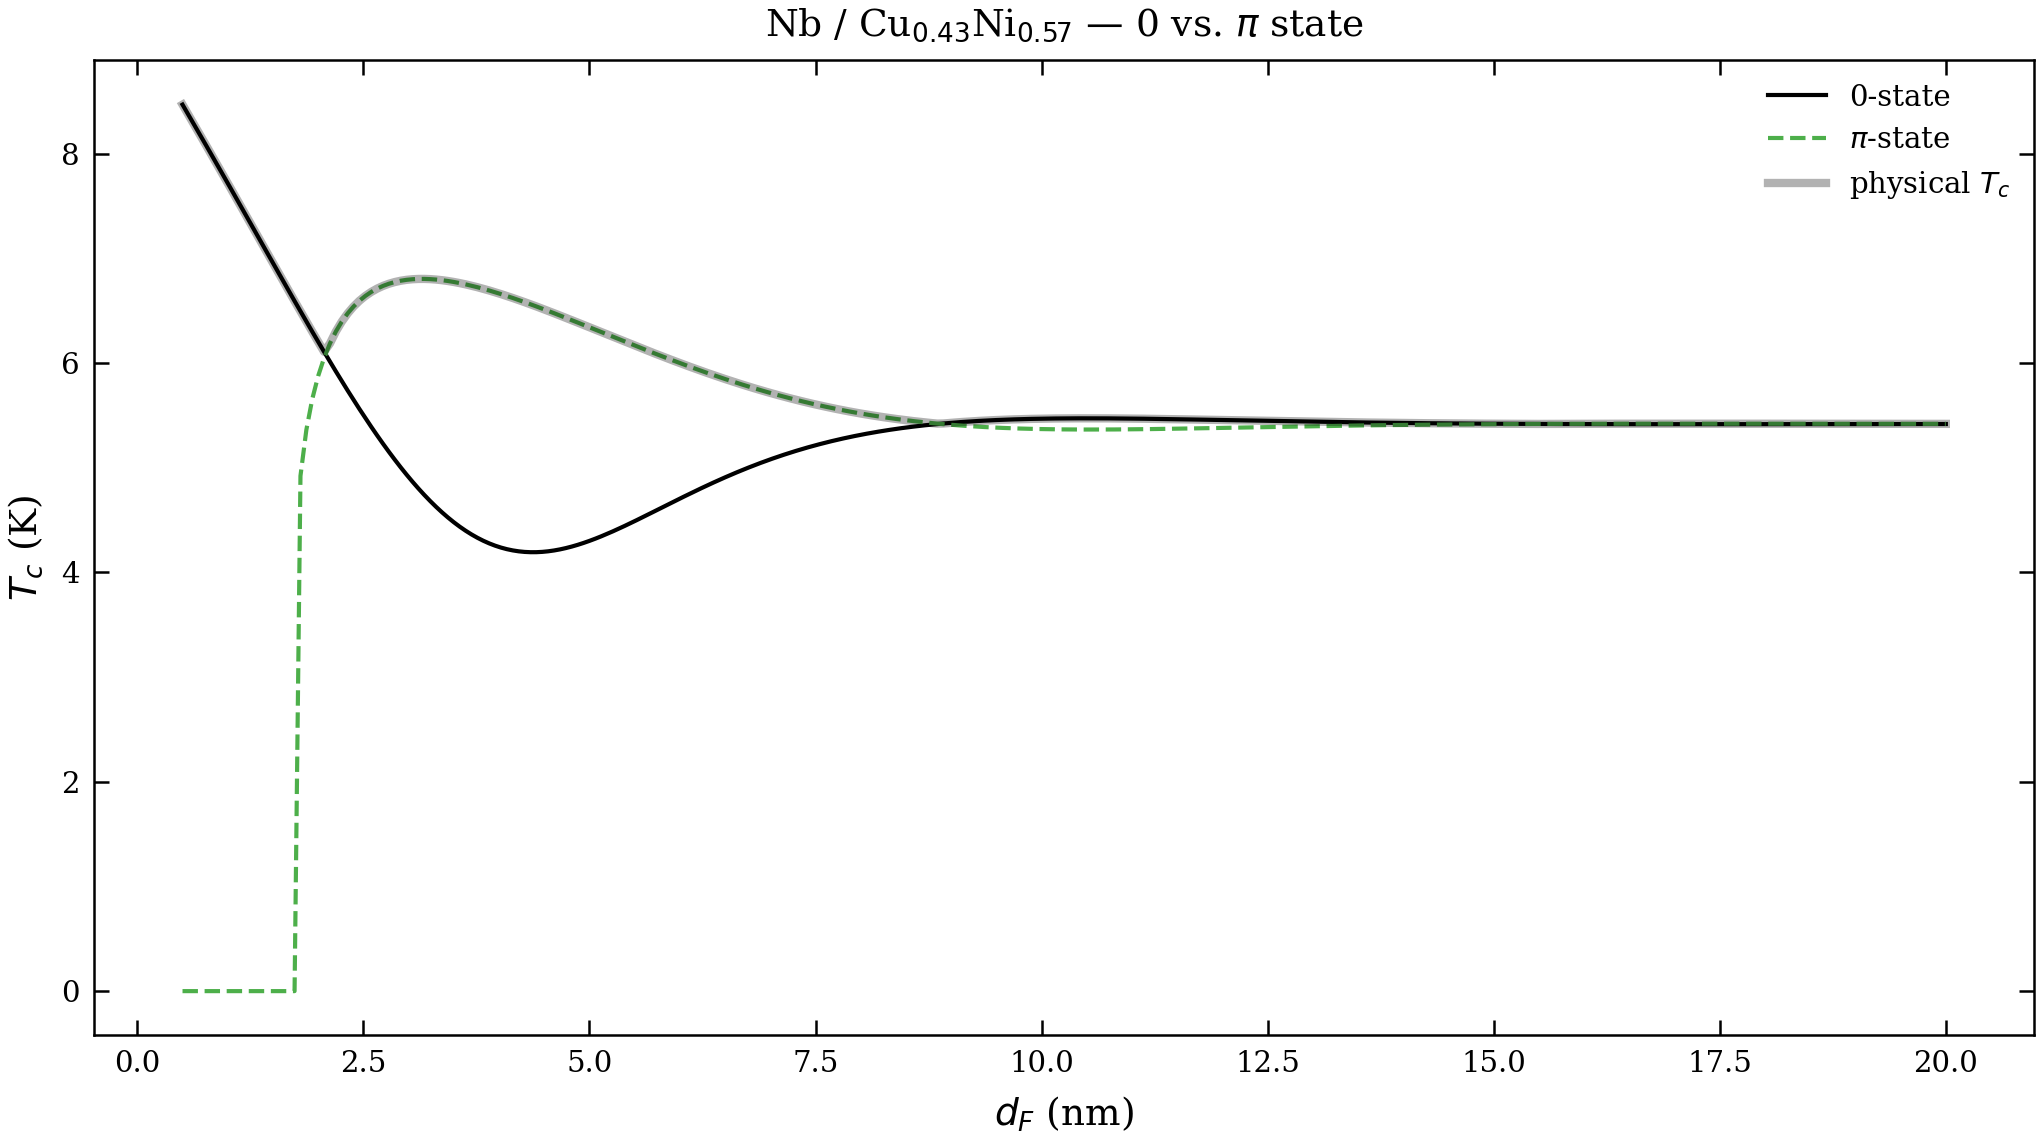

In [2]:
nb   = supermag.get_material("Nb")
cuni = supermag.get_material("Cu0.43Ni0.57")

d_F = np.linspace(0.5, 20.0, 300)

Tc_zero = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_F,
    E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
    gamma=0.20, gamma_B=0.0, model="thin_s", phase="zero")

Tc_pi = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_F,
    E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
    gamma=0.20, gamma_B=0.0, model="thin_s", phase="pi")

Tc_phys = np.maximum(Tc_zero, Tc_pi)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d_F, Tc_zero, "C0-", label="0-state")
ax.plot(d_F, Tc_pi,   "C3--", label=r"$\pi$-state")
ax.plot(d_F, Tc_phys, "k-", lw=2, alpha=0.3, label=r"physical $T_c$")
ax.set_xlabel(r"$d_F$ (nm)")
ax.set_ylabel(r"$T_c$ (K)")
ax.legend()
ax.set_title(r"Nb / Cu$_{0.43}$Ni$_{0.57}$ — 0 vs. $\pi$ state")
plt.tight_layout()

## 2. Locate the 0–π crossover

The transition occurs where $T_c$("zero") = $T_c$("pi").  We find
crossings by detecting sign changes in $\Delta T_c = T_{c,0} - T_{c,\pi}$.

In [3]:
delta_Tc = Tc_zero - Tc_pi
crossings = []
for i in range(len(delta_Tc) - 1):
    if delta_Tc[i] * delta_Tc[i + 1] < 0:
        # Linear interpolation
        d_cross = (d_F[i] - delta_Tc[i]
                   * (d_F[i + 1] - d_F[i])
                   / (delta_Tc[i + 1] - delta_Tc[i]))
        crossings.append(d_cross)

for j, dc in enumerate(crossings):
    print(f"Crossing {j + 1}: d_F = {dc:.2f} nm")

Crossing 1: d_F = 2.08 nm
Crossing 2: d_F = 8.87 nm
Crossing 3: d_F = 15.47 nm


## 3. Multi-material phase diagram

Compare the 0–π boundary for three ferromagnets with
different exchange strengths: CuNi (weak), Py (intermediate),
and Ni (strong).

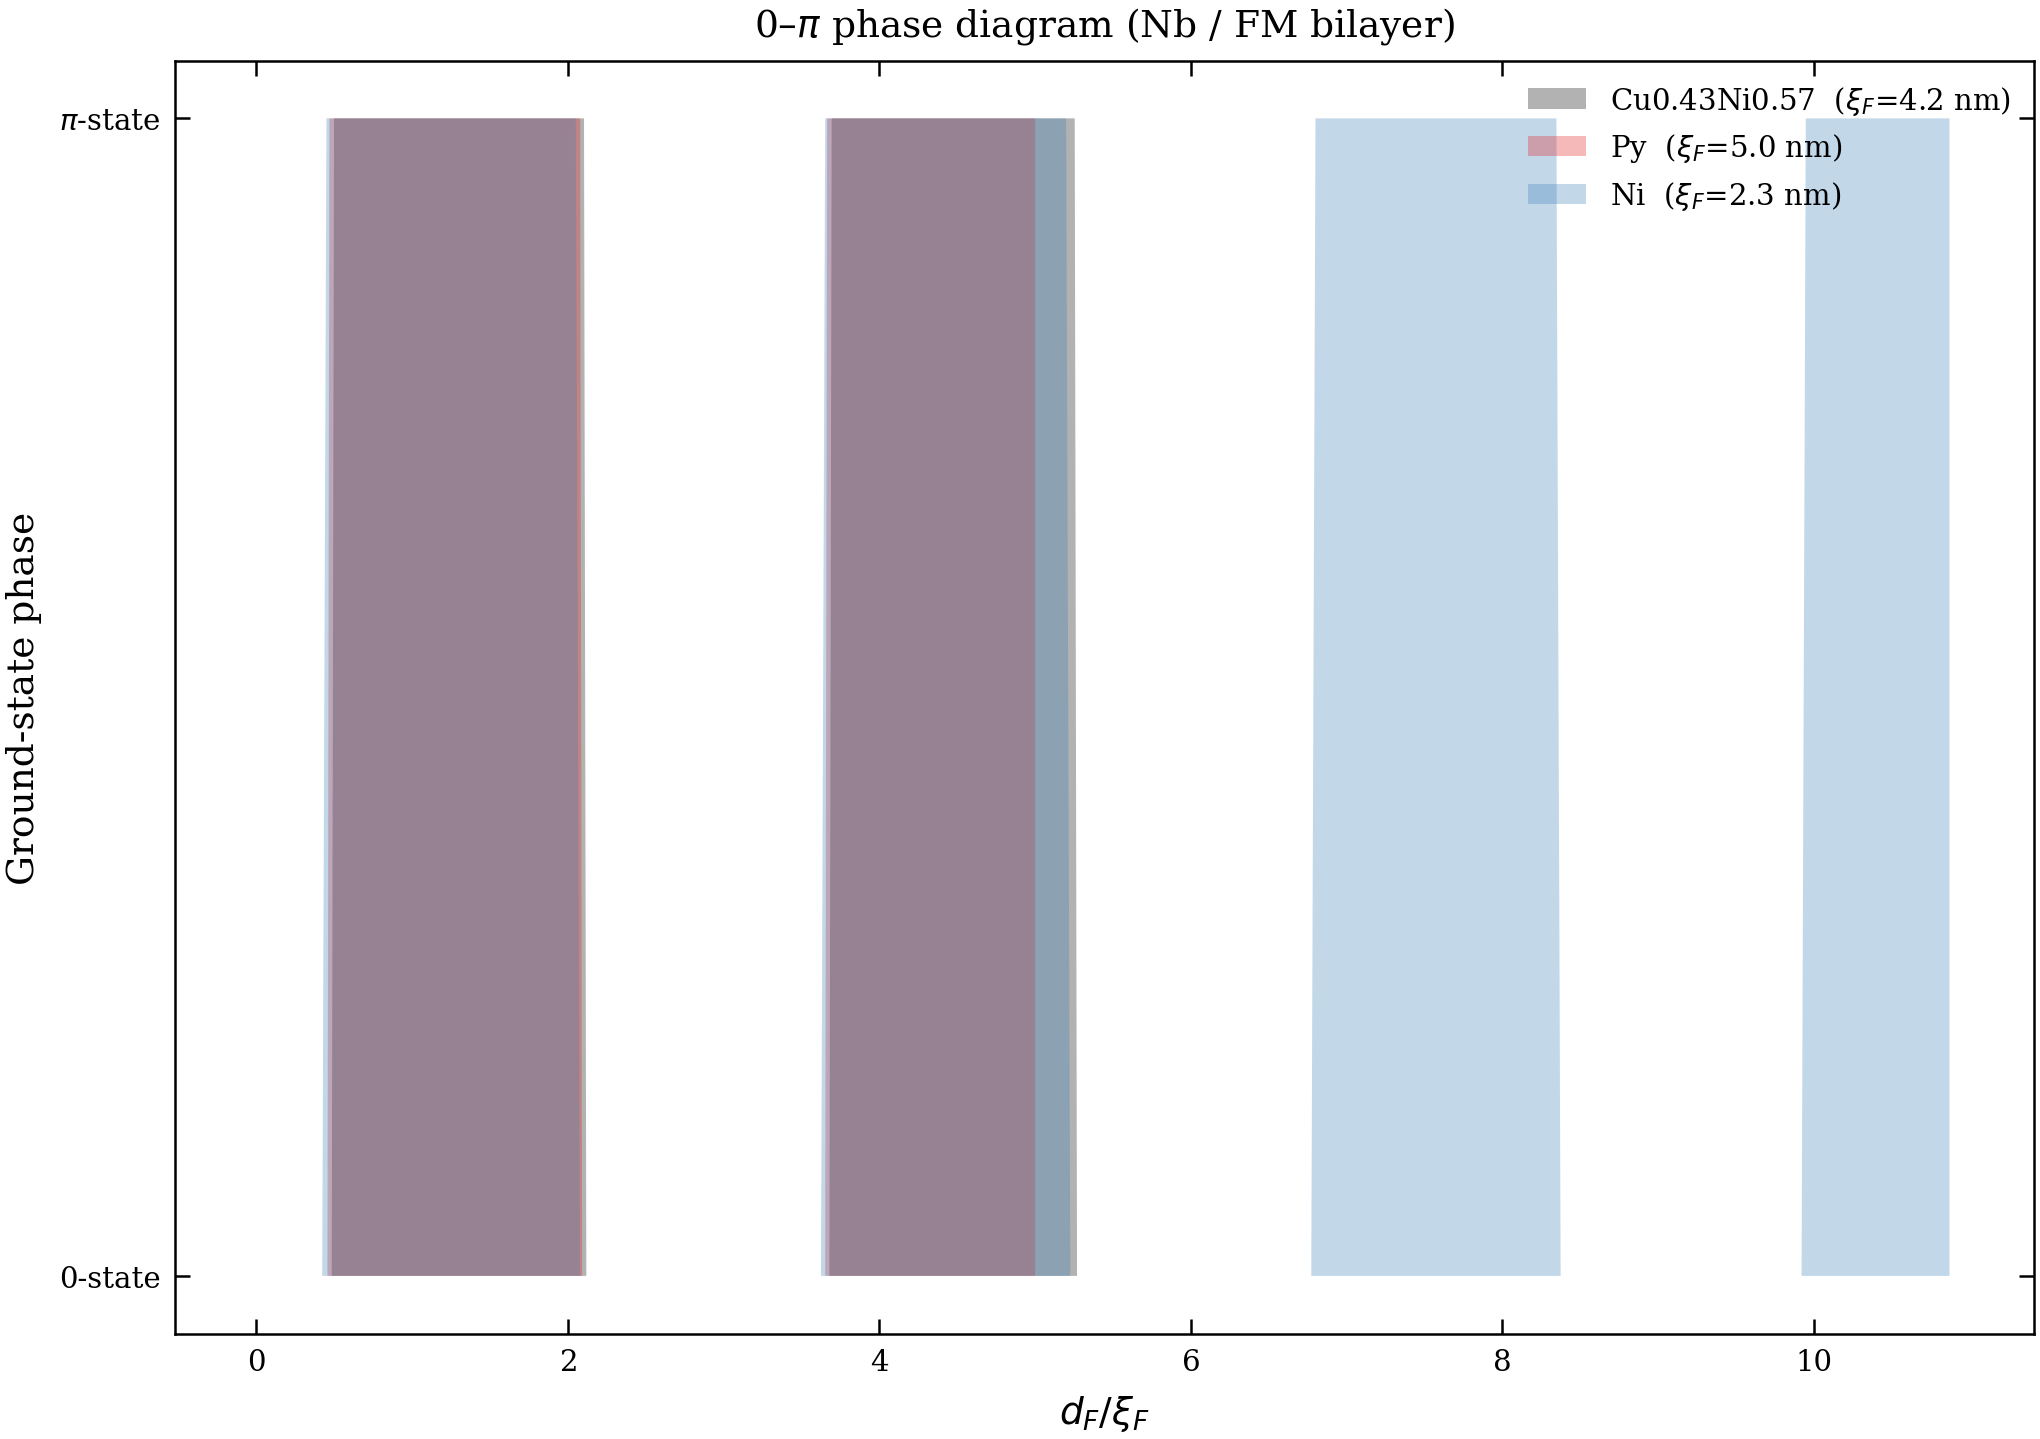

In [4]:
materials = [
    ("Cu0.43Ni0.57", 0.20),
    ("Py",           0.15),
    ("Ni",           0.30),
]

fig, ax = plt.subplots(figsize=(7, 5))

for fm_name, gam in materials:
    fm = supermag.get_material(fm_name)
    d_max = 25.0 if fm["xi_F"] > 2 else 5.0
    d_range = np.linspace(0.1, d_max, 400)

    Tc0_arr = supermag.critical_temperature(
        Tc0=nb["Tc"], d_S=50.0, d_F_array=d_range,
        E_ex=fm["E_ex"], xi_S=nb["xi_S"], xi_F=fm["xi_F"],
        gamma=gam, gamma_B=0.0, model="thin_s", phase="zero")
    Tcpi_arr = supermag.critical_temperature(
        Tc0=nb["Tc"], d_S=50.0, d_F_array=d_range,
        E_ex=fm["E_ex"], xi_S=nb["xi_S"], xi_F=fm["xi_F"],
        gamma=gam, gamma_B=0.0, model="thin_s", phase="pi")

    # Phase indicator: 0 = 0-state, 1 = pi-state
    phase = np.where(Tc0_arr >= Tcpi_arr, 0, 1)
    ax.fill_between(d_range / fm["xi_F"], phase, alpha=0.3,
                    label=rf"{fm_name}  ($\xi_F$={fm['xi_F']} nm)")

ax.set_xlabel(r"$d_F / \xi_F$")
ax.set_ylabel("Ground-state phase")
ax.set_yticks([0, 1])
ax.set_yticklabels(["0-state", r"$\pi$-state"])
ax.legend(loc="upper right")
ax.set_title(r"0–$\pi$ phase diagram (Nb / FM bilayer)")
plt.tight_layout()

## 4. π-junction sweet spot

A robust π-junction should be deep in the π-state, far from
both crossover boundaries.  We quantify this by the **π-state
margin**: $\Delta T_c = T_{c,\pi} - T_{c,0}$ (positive when the
π-state is preferred).

Sweet spot: d_F = 4.02 nm, margin = 2.421 K


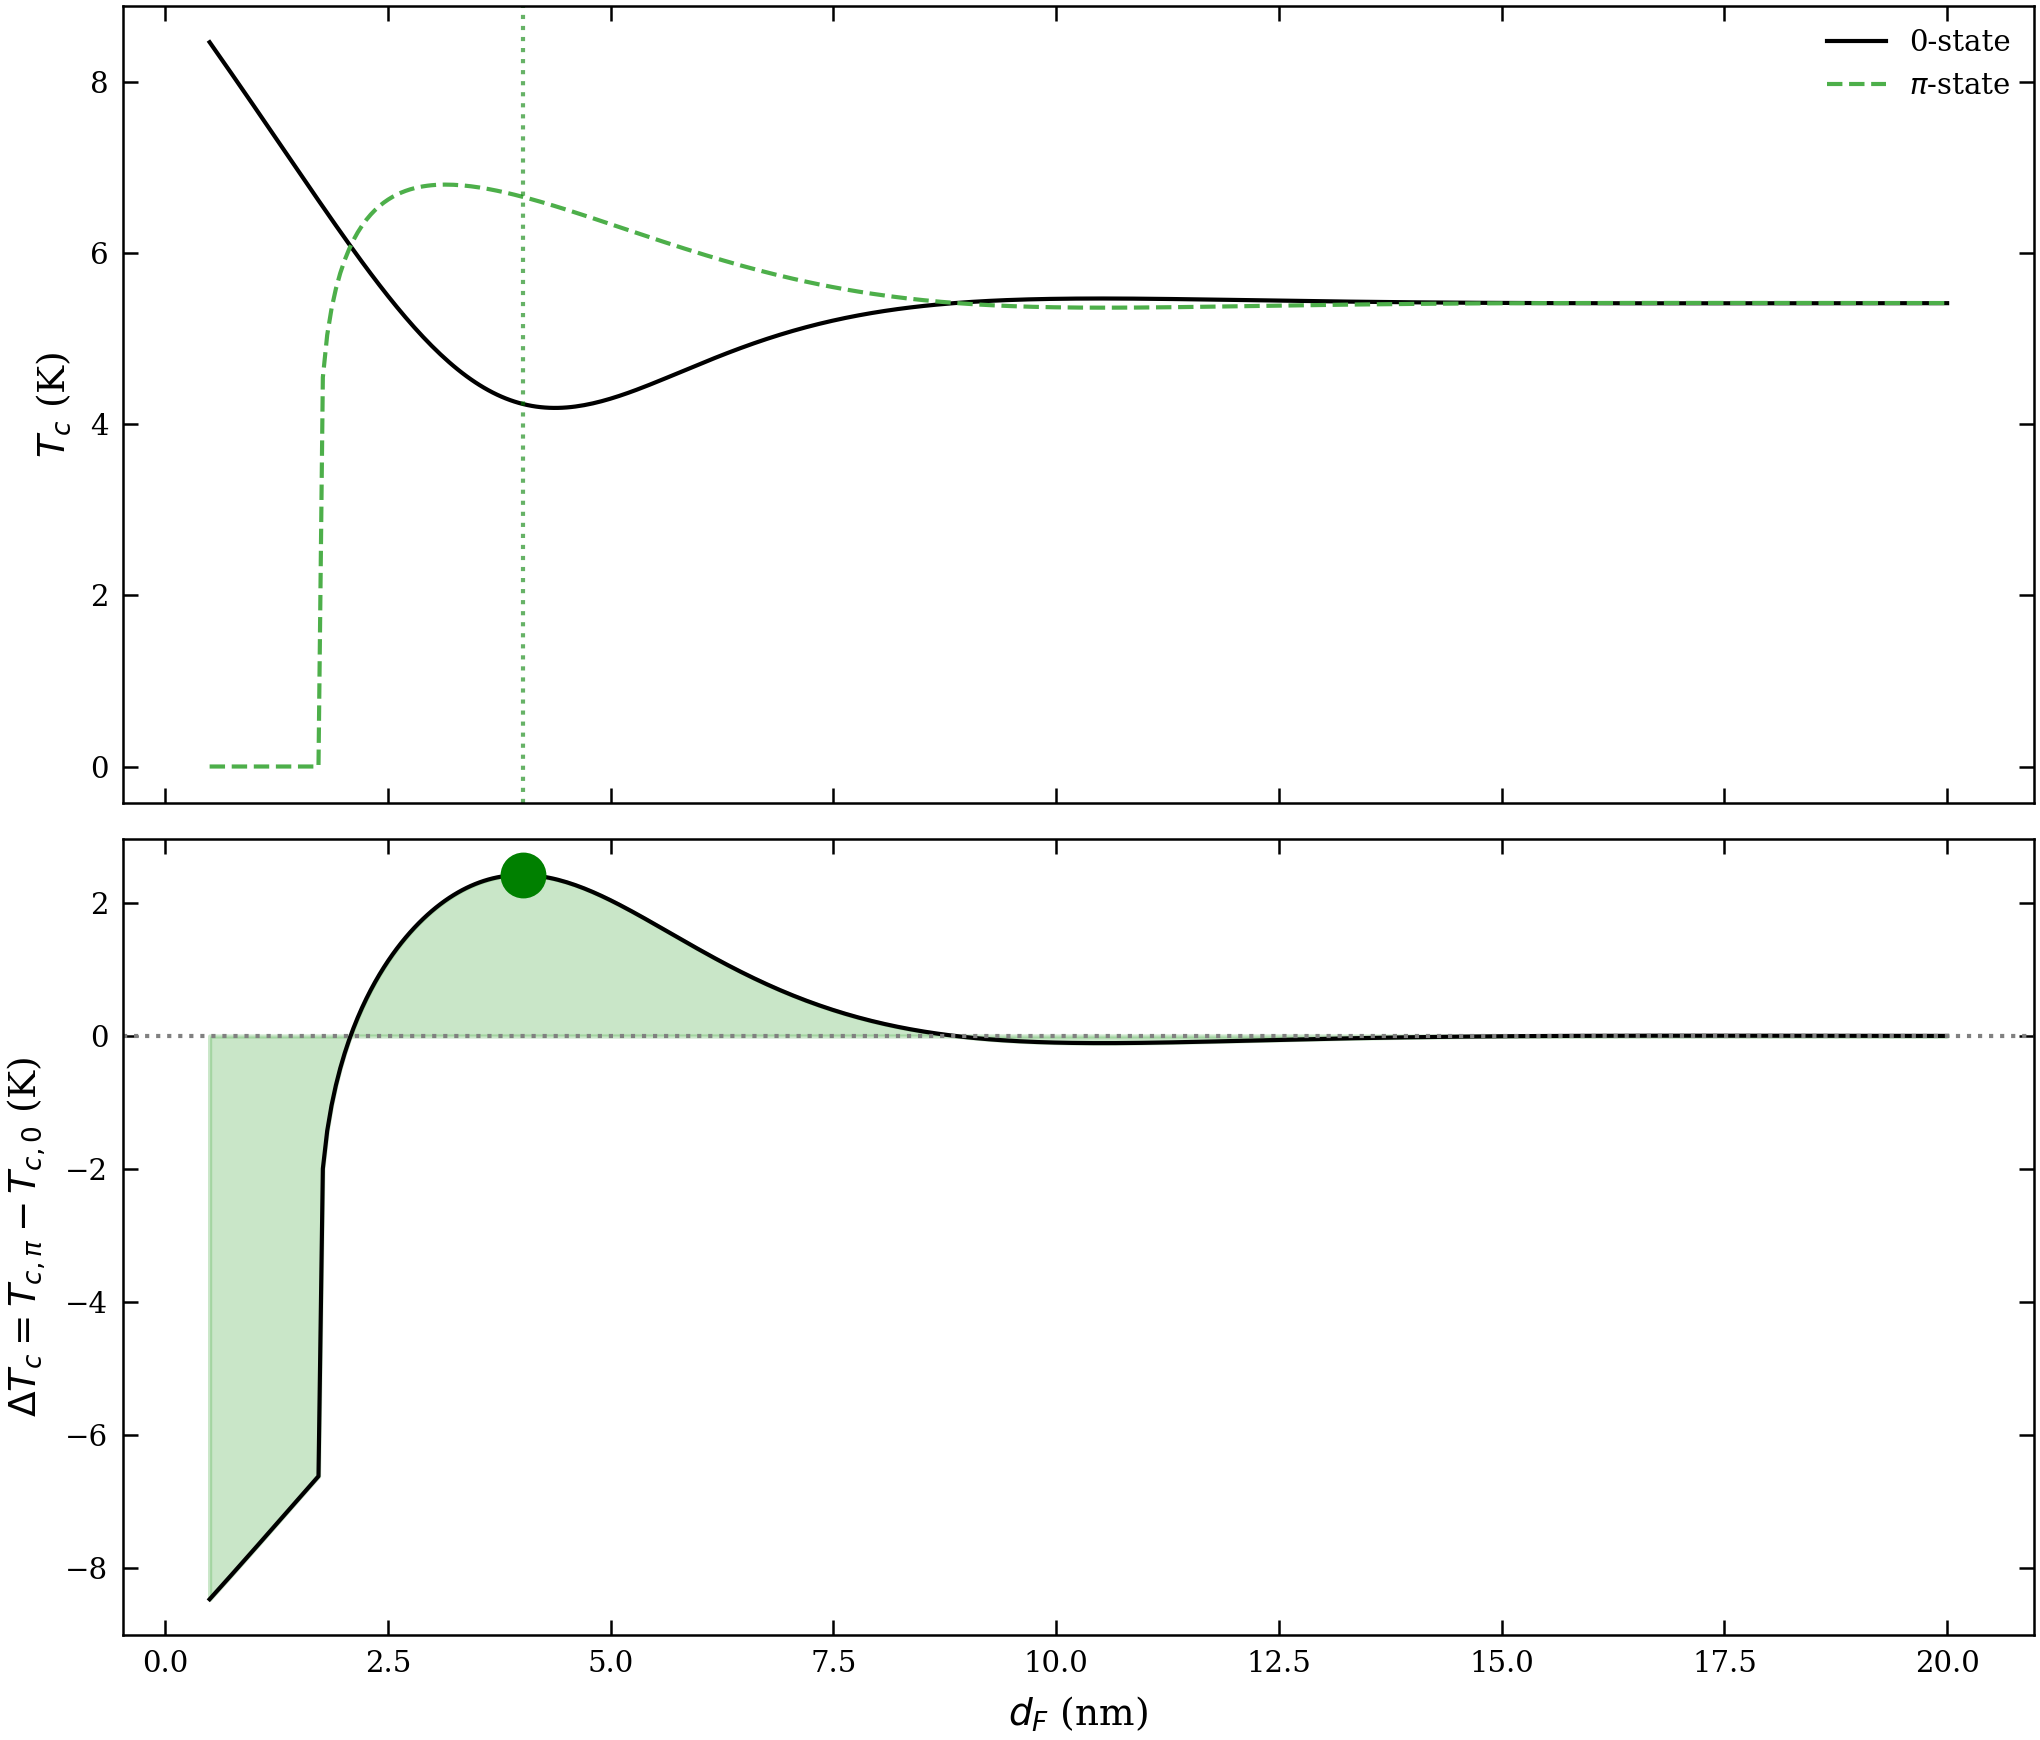

In [5]:
d_range = np.linspace(0.5, 20.0, 400)

Tc_0 = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_range,
    E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
    gamma=0.20, gamma_B=0.0, model="thin_s", phase="zero")
Tc_p = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_range,
    E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
    gamma=0.20, gamma_B=0.0, model="thin_s", phase="pi")

margin = Tc_p - Tc_0
i_sweet = np.argmax(margin)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

ax1.plot(d_range, Tc_0, "C0-", label="0-state")
ax1.plot(d_range, Tc_p, "C3--", label=r"$\pi$-state")
ax1.axvline(d_range[i_sweet], ls=":", color="green", alpha=0.6)
ax1.set_ylabel(r"$T_c$ (K)")
ax1.legend()

ax2.fill_between(d_range, margin, alpha=0.3, color="C3")
ax2.plot(d_range, margin, "k-")
ax2.axhline(0, ls=":", color="gray")
ax2.plot(d_range[i_sweet], margin[i_sweet], "go", ms=10)
ax2.set_xlabel(r"$d_F$ (nm)")
ax2.set_ylabel(r"$\Delta T_c = T_{c,\pi} - T_{c,0}$ (K)")

print(f"Sweet spot: d_F = {d_range[i_sweet]:.2f} nm, "
      f"margin = {margin[i_sweet]:.3f} K")
plt.tight_layout()

## 5. Effect of interface barrier

A finite $\gamma_B$ (interface barrier) shifts the 0–π boundary.
Compare clean ($\gamma_B = 0$) and sputtered ($\gamma_B = 0.1$) interfaces.

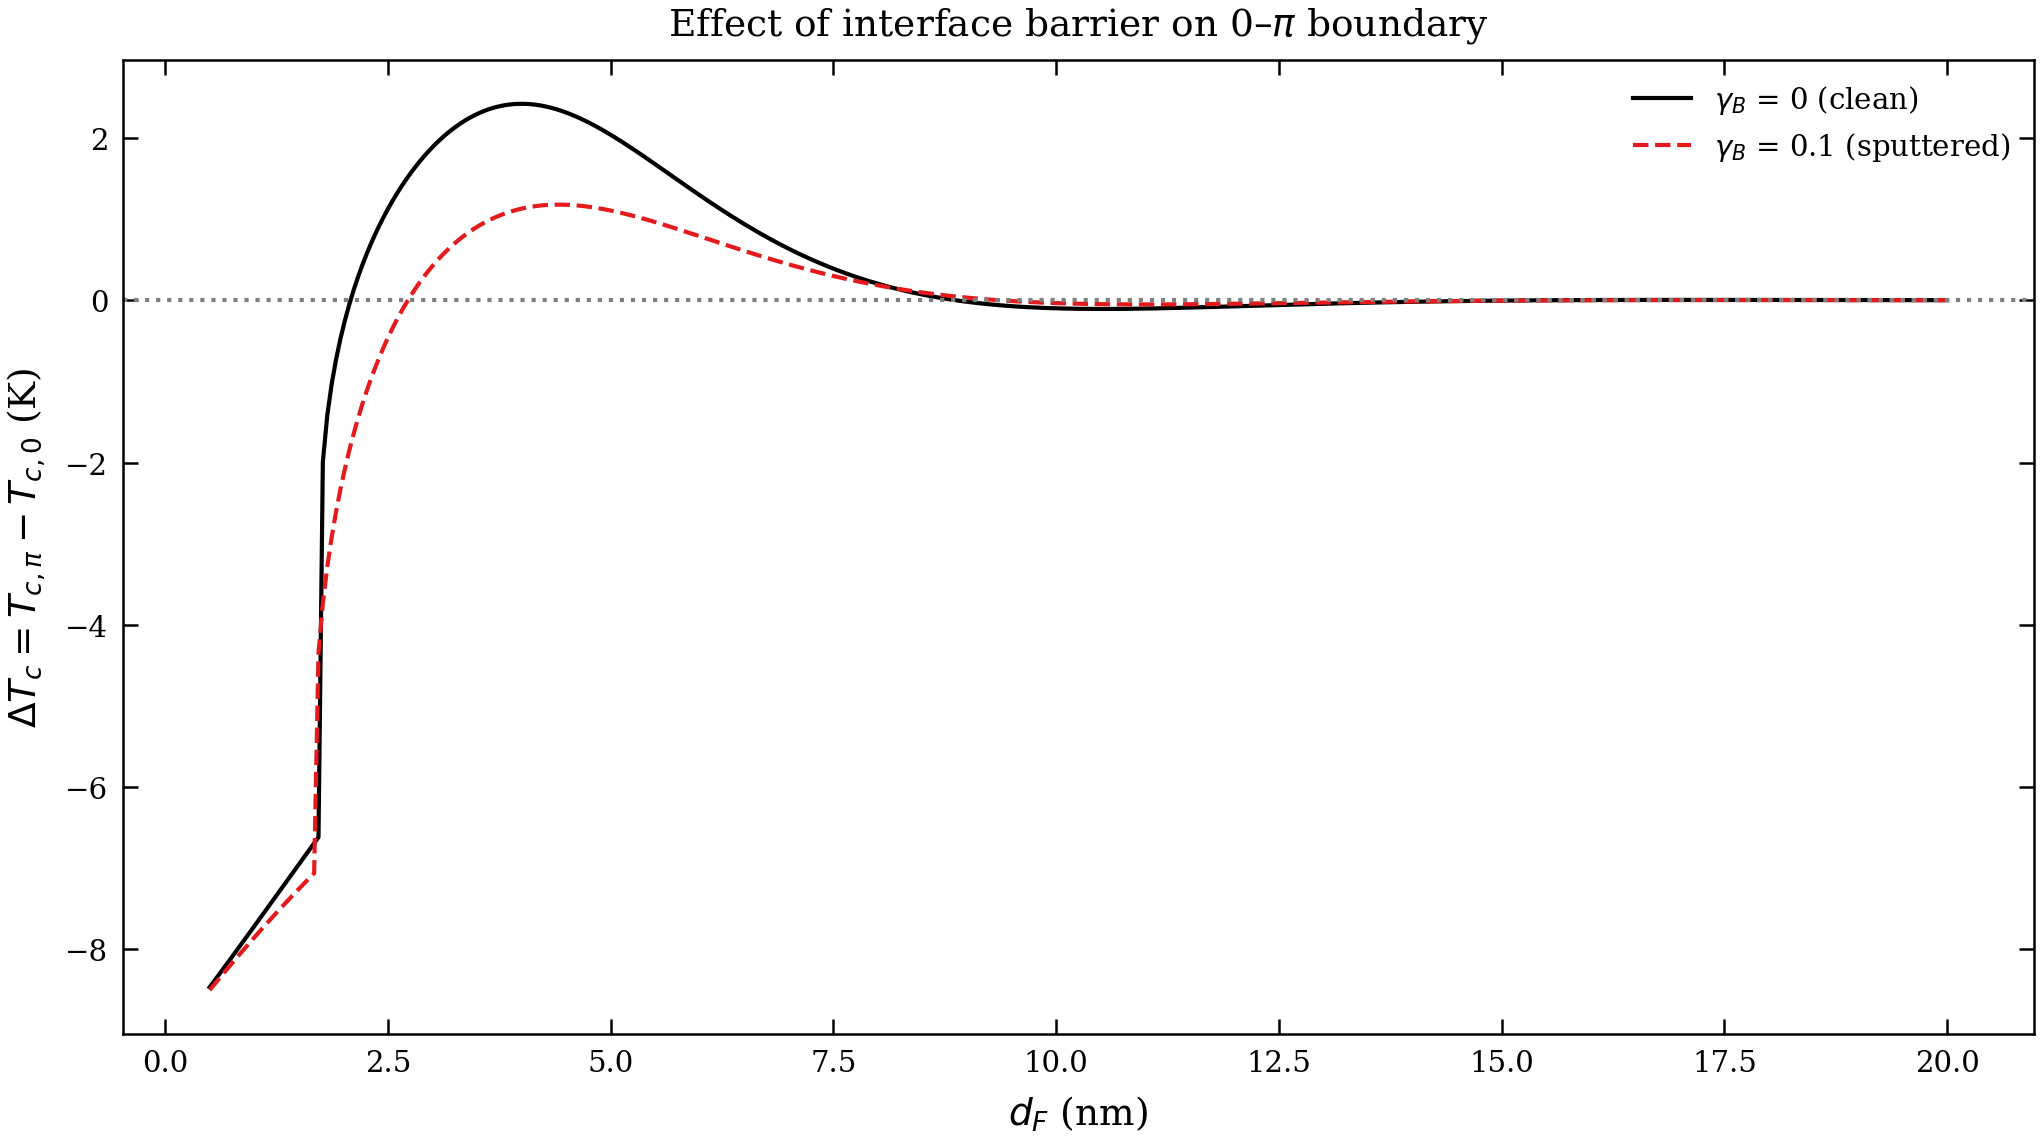

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

for gB, ls, label in [(0.0, "-", r"$\gamma_B$ = 0 (clean)"),
                      (0.1, "--", r"$\gamma_B$ = 0.1 (sputtered)")]:
    Tc0_line = supermag.critical_temperature(
        Tc0=nb["Tc"], d_S=50.0, d_F_array=d_range,
        E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
        gamma=0.20, gamma_B=gB, model="thin_s", phase="zero")
    Tcpi_line = supermag.critical_temperature(
        Tc0=nb["Tc"], d_S=50.0, d_F_array=d_range,
        E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
        gamma=0.20, gamma_B=gB, model="thin_s", phase="pi")
    m = Tcpi_line - Tc0_line
    ax.plot(d_range, m, ls, label=label)

ax.axhline(0, ls=":", color="gray")
ax.set_xlabel(r"$d_F$ (nm)")
ax.set_ylabel(r"$\Delta T_c = T_{c,\pi} - T_{c,0}$ (K)")
ax.set_title(r"Effect of interface barrier on 0–$\pi$ boundary")
ax.legend()
plt.tight_layout()

## Summary

| Material | $\xi_F$ (nm) | $\pi$-onset $d_F$ | Sweet-spot $d_F$ |
|----------|-------------|-------------------|------------------|
| CuNi     | 4.2         | ~3 nm             | ~5 nm            |
| Py       | 5.0         | ~4 nm             | ~7 nm            |
| Ni       | 2.3         | ~2 nm             | ~3 nm            |

A robust π-junction sits at the **sweet spot** where the π-state
margin is maximised — far enough from the 0–π boundary that
fabrication thickness variations don’t accidentally flip the phase.